In [1]:
# =========================================================
# Day 3. 지도학습 - 분류 실습
# 실제 업로드 파일 기준: supervised_label_cn7.csv
#
# 목표
# 1) PassOrFail 예측 문제 정의
# 2) train/test split
# 3) baseline 모델
# 4) confusion matrix / classification report 해석
# 5) class imbalance 대응(class_weight, oversampling)
# 6) 하이퍼파라미터 튜닝
# 7) 중요 변수 해석
# =========================================================

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# ---------------------------------------------------------
# 1. 라이브러리 불러오기
# ---------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [4]:
# ---------------------------------------------------------
# 2. 기본 설정
# ---------------------------------------------------------
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 100)
np.random.seed(42)

In [5]:
# ---------------------------------------------------------
# 3. 데이터 불러오기
# ---------------------------------------------------------
file_path = "supervised_label_cn7.csv"
df = pd.read_csv(file_path)

print("=== 원본 데이터 상위 5행 ===")
display(df.head())

=== 원본 데이터 상위 5행 ===


,Unnamed: 0,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
0,0,0,9.60,4.48,16.91,59.580002,7.13,653.409973,68.839996,647.98999,55.299999,30.799999,292.500000,141.800003,136.899994,37.500000,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.6
1,1,0,9.59,4.48,16.91,59.560001,7.13,653.419983,68.839996,647.98999,55.299999,31.000000,292.500000,141.800003,136.800003,37.500000,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.6
2,2,0,9.58,4.46,16.90,59.580002,7.13,653.409973,68.839996,647.98999,55.599998,30.900000,292.500000,141.699997,136.399994,37.700001,59.400002,276.299988,275.299988,275.200012,271.399994,255.000000,230.000000,67.500000,25.000000,27.6
3,3,0,9.58,4.46,16.92,59.560001,7.13,653.409973,68.849998,647.98999,55.500000,30.600000,292.399994,141.800003,136.699997,37.400002,59.299999,275.799988,275.399994,275.000000,271.299988,255.000000,230.000000,67.000000,25.000000,27.6
4,4,0,9.57,4.45,16.91,59.520000,7.14,653.409973,68.830002,647.98999,55.700001,30.799999,292.500000,141.600006,136.399994,37.099998,59.099998,275.700012,274.899994,274.799988,270.799988,255.399994,230.100006,66.699997,24.799999,27.5


In [6]:
# ---------------------------------------------------------
# 4. 불필요 컬럼 제거
# ---------------------------------------------------------
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("=== 컬럼 정리 후 상위 5행 ===")
display(df.head())

=== 컬럼 정리 후 상위 5행 ===


,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
0,0,9.60,4.48,16.91,59.580002,7.13,653.409973,68.839996,647.98999,55.299999,30.799999,292.500000,141.800003,136.899994,37.500000,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.6
1,0,9.59,4.48,16.91,59.560001,7.13,653.419983,68.839996,647.98999,55.299999,31.000000,292.500000,141.800003,136.800003,37.500000,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.6
2,0,9.58,4.46,16.90,59.580002,7.13,653.409973,68.839996,647.98999,55.599998,30.900000,292.500000,141.699997,136.399994,37.700001,59.400002,276.299988,275.299988,275.200012,271.399994,255.000000,230.000000,67.500000,25.000000,27.6
3,0,9.58,4.46,16.92,59.560001,7.13,653.409973,68.849998,647.98999,55.500000,30.600000,292.399994,141.800003,136.699997,37.400002,59.299999,275.799988,275.399994,275.000000,271.299988,255.000000,230.000000,67.000000,25.000000,27.6
4,0,9.57,4.45,16.91,59.520000,7.14,653.409973,68.830002,647.98999,55.700001,30.799999,292.500000,141.600006,136.399994,37.099998,59.099998,275.700012,274.899994,274.799988,270.799988,255.399994,230.100006,66.699997,24.799999,27.5


In [7]:
# ---------------------------------------------------------
# 5. 데이터 기본 확인
# ---------------------------------------------------------
print("=== 데이터 크기 ===")
print(df.shape)

=== 데이터 크기 ===
(6736, 25)


In [8]:
print("\n=== 데이터 정보 ===")
df.info()


=== 데이터 정보 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6736 entries, 0 to 6735
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PassOrFail                6736 non-null   int64  
 1   Injection_Time            6736 non-null   float64
 2   Filling_Time              6736 non-null   float64
 3   Plasticizing_Time         6736 non-null   float64
 4   Cycle_Time                6736 non-null   float64
 5   Clamp_Close_Time          6736 non-null   float64
 6   Cushion_Position          6736 non-null   float64
 7   Plasticizing_Position     6736 non-null   float64
 8   Clamp_Open_Position       6736 non-null   float64
 9   Max_Injection_Speed       6736 non-null   float64
 10  Max_Screw_RPM             6736 non-null   float64
 11  Average_Screw_RPM         6736 non-null   float64
 12  Max_Injection_Pressure    6736 non-null   float64
 13  Max_Switch_Over_Pressure  6736 non-null   float

In [9]:
print("\n=== PassOrFail 분포 ===")
display(df["PassOrFail"].value_counts().sort_index())


=== PassOrFail 분포 ===


PassOrFail
0    6697
1      39
Name: count, dtype: int64

In [10]:
print("\n=== PassOrFail 비율(%) ===")
display((df["PassOrFail"].value_counts(normalize=True).sort_index() * 100).round(3))


=== PassOrFail 비율(%) ===


PassOrFail
0    99.421
1     0.579
Name: proportion, dtype: float64

In [11]:
# ---------------------------------------------------------
# 6. 데이터(X) / 정답(y) 분리
# ---------------------------------------------------------
target_col = "PassOrFail"
X = df.drop(columns=[target_col])
y = df[target_col]

print("=== X, y 크기 ===")
print("X shape:", X.shape)
print("y shape:", y.shape)

=== X, y 크기 ===
X shape: (6736, 24)
y shape: (6736,)


In [12]:
print("\n=== 컬럼 목록 ===")
print(X.columns.tolist())


=== 컬럼 목록 ===
['Injection_Time', 'Filling_Time', 'Plasticizing_Time', 'Cycle_Time', 'Clamp_Close_Time', 'Cushion_Position', 'Plasticizing_Position', 'Clamp_Open_Position', 'Max_Injection_Speed', 'Max_Screw_RPM', 'Average_Screw_RPM', 'Max_Injection_Pressure', 'Max_Switch_Over_Pressure', 'Max_Back_Pressure', 'Average_Back_Pressure', 'Barrel_Temperature_1', 'Barrel_Temperature_2', 'Barrel_Temperature_3', 'Barrel_Temperature_4', 'Barrel_Temperature_5', 'Barrel_Temperature_6', 'Hopper_Temperature', 'Mold_Temperature_3', 'Mold_Temperature_4']


In [13]:
# ---------------------------------------------------------
# 7. train / test 분리
#    - 불균형 데이터이므로 stratify 사용
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("=== train / test 크기 ===")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

=== train / test 크기 ===
X_train: (5388, 24)
X_test : (1348, 24)
y_train: (5388,)
y_test : (1348,)


In [14]:
print("\n=== train target 분포 ===")
display(y_train.value_counts().sort_index())


=== train target 분포 ===


PassOrFail
0    5357
1      31
Name: count, dtype: int64

In [15]:
print("\n=== test target 분포 ===")
display(y_test.value_counts().sort_index())


=== test target 분포 ===


PassOrFail
0    1340
1       8
Name: count, dtype: int64

In [16]:
# ---------------------------------------------------------
# 8. 공통 평가 함수 (model 객체를 포함하여 리턴)
# ---------------------------------------------------------
def evaluate_binary_model(model, X_train, y_train, X_test, y_test, model_name="model"):
    # 모델 학습
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = None

    # 평가지표 계산
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_score) if y_score is not None else np.nan

    # 결과 출력 (선택 사항)
    print(f"--- {model_name} Evaluation Completed ---")
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1-score :", round(f1, 4))

    if y_score is not None:
        roc_auc = roc_auc_score(y_test, y_score)
        print("ROC-AUC  :", round(roc_auc, 4))
    else:
        roc_auc = np.nan
        print("ROC-AUC  : 계산 불가")

    print("\n[Classification Report]")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.show()

    # ★ 핵심: 학습된 model 객체와 지표들을 함께 리턴
    return {
        "model_name": model_name,
        "model": model,  # 학습된 모델 객체
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc_auc
    }


--- Logistic Regression Evaluation Completed ---
Accuracy : 0.9978
Precision: 1.0
Recall   : 0.625
F1-score : 0.7692
ROC-AUC  : 0.9277

[Classification Report]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1340
           1       1.00      0.62      0.77         8

    accuracy                           1.00      1348
   macro avg       1.00      0.81      0.88      1348
weighted avg       1.00      1.00      1.00      1348



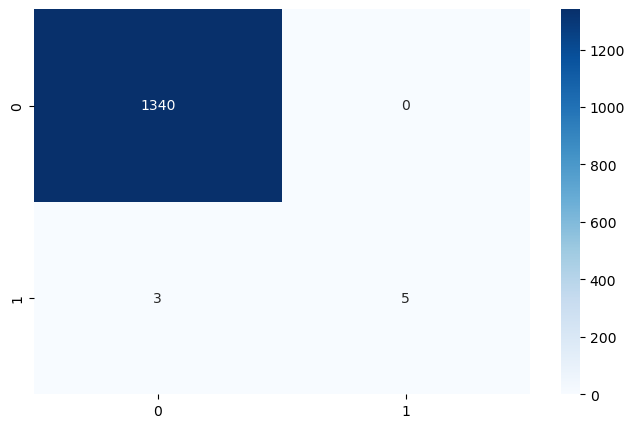

--- Decision Tree Evaluation Completed ---
Accuracy : 0.9955
Precision: 0.625
Recall   : 0.625
F1-score : 0.625
ROC-AUC  : 0.8116

[Classification Report]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1340
           1       0.62      0.62      0.62         8

    accuracy                           1.00      1348
   macro avg       0.81      0.81      0.81      1348
weighted avg       1.00      1.00      1.00      1348



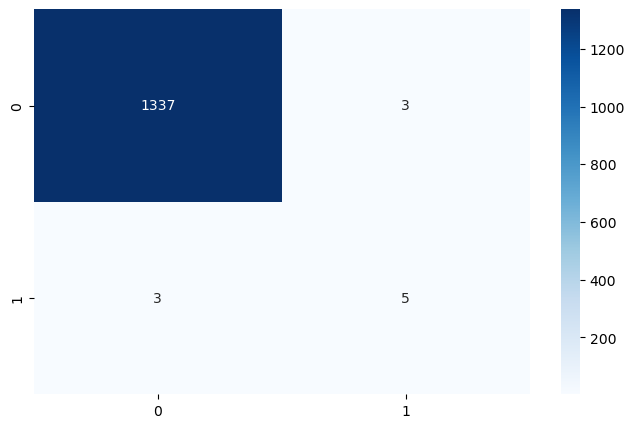

--- Random Forest Evaluation Completed ---
Accuracy : 0.9955
Precision: 0.625
Recall   : 0.625
F1-score : 0.625
ROC-AUC  : 0.931

[Classification Report]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1340
           1       0.62      0.62      0.62         8

    accuracy                           1.00      1348
   macro avg       0.81      0.81      0.81      1348
weighted avg       1.00      1.00      1.00      1348



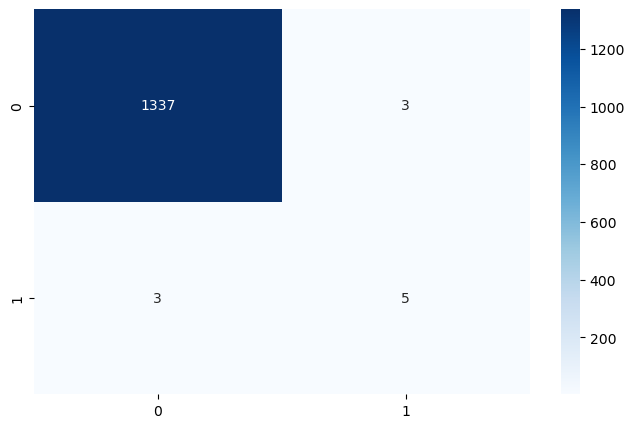


=== Baseline 모델 비교표 ===


,model_name,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.997774,1.000,0.625,0.769231,0.927659
1,Decision Tree,0.995549,0.625,0.625,0.625000,0.811614
2,Random Forest,0.995549,0.625,0.625,0.625000,0.931017


In [17]:
# ---------------------------------------------------------
# 9~11. 모델별 실행 및 결과 수집
# ---------------------------------------------------------
# 각 모델의 실행 결과를 변수에 담습니다.
result_log = evaluate_binary_model(
    LogisticRegression(max_iter=3000, random_state=42),
    X_train, y_train, X_test, y_test, "Logistic Regression"
)

result_tree = evaluate_binary_model(
    DecisionTreeClassifier(random_state=42),
    X_train, y_train, X_test, y_test, "Decision Tree"
)

result_rf = evaluate_binary_model(
    RandomForestClassifier(n_estimators=300, random_state=42),
    X_train, y_train, X_test, y_test, "Random Forest"
)

# ---------------------------------------------------------
# 12. baseline 모델 비교표 (통합 리턴된 리스트 사용)
# ---------------------------------------------------------
# 리턴된 딕셔너리들을 리스트로 묶어 바로 DataFrame으로 만듭니다.
baseline_compare = pd.DataFrame([
    result_log,
    result_tree,
    result_rf
]).sort_values("f1", ascending=False)

# 시각화 시 모델 객체 컬럼은 제외하고 보여주는 것이 깔끔합니다.
print("\n=== Baseline 모델 비교표 ===")
display(baseline_compare.drop(columns=['model']))

# 이후 특정 모델이 필요하면?
# best_model = result_rf['model'] 과 같이 언제든 꺼내 쓸 수 있습니다.

--- Logistic Regression (Balanced) Evaluation Completed ---
Accuracy : 0.9592
Precision: 0.0877
Recall   : 0.625
F1-score : 0.1538
ROC-AUC  : 0.9565

[Classification Report]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1340
           1       0.09      0.62      0.15         8

    accuracy                           0.96      1348
   macro avg       0.54      0.79      0.57      1348
weighted avg       0.99      0.96      0.97      1348



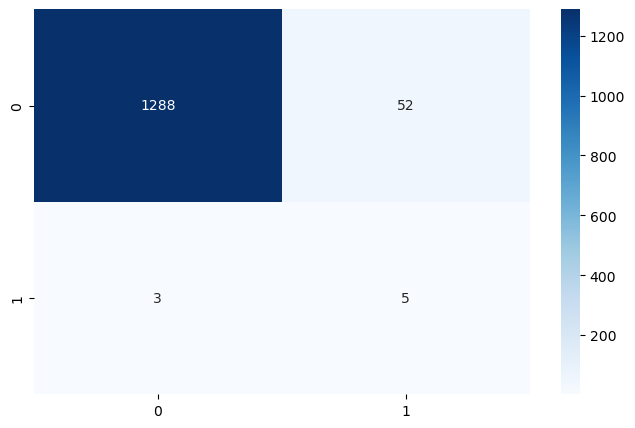

--- Random Forest (Balanced) Evaluation Completed ---
Accuracy : 0.9955
Precision: 0.625
Recall   : 0.625
F1-score : 0.625
ROC-AUC  : 0.9959

[Classification Report]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1340
           1       0.62      0.62      0.62         8

    accuracy                           1.00      1348
   macro avg       0.81      0.81      0.81      1348
weighted avg       1.00      1.00      1.00      1348



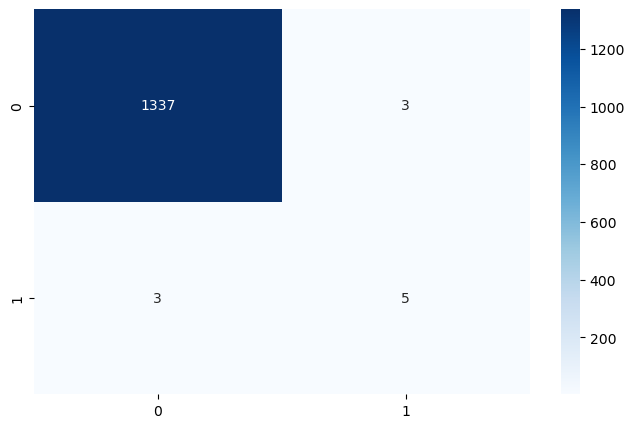

=== class_weight 적용 전후 비교 ===


,model_name,accuracy,precision,recall,f1
0,Logistic Regression,0.997774,1.000000,0.625,0.769231
1,Logistic Regression (Balanced),0.959199,0.087719,0.625,0.153846
2,Random Forest,0.995549,0.625000,0.625,0.625000
3,Random Forest (Balanced),0.995549,0.625000,0.625,0.625000


In [18]:
# ---------------------------------------------------------
# 13. class_weight='balanced' 적용 및 실행
# ---------------------------------------------------------
# Logistic Regression (Balanced)
result_log_balanced = evaluate_binary_model(
    LogisticRegression(max_iter=3000, random_state=42, class_weight="balanced"),
    X_train, y_train, X_test, y_test,
    model_name="Logistic Regression (Balanced)"
)

# Random Forest (Balanced)
result_rf_balanced = evaluate_binary_model(
    RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced"),
    X_train, y_train, X_test, y_test,
    model_name="Random Forest (Balanced)"
)

# ---------------------------------------------------------
# 14. class_weight 적용 전후 비교표 생성
# ---------------------------------------------------------
# 이전에 생성한 result_log, result_rf와 이번에 생성한 balanced 결과를 통합 리스트로 만듭니다.
balanced_compare = pd.DataFrame([
    result_log,
    result_log_balanced,
    result_rf,
    result_rf_balanced
])

# 불필요한 컬럼(model 객체 등)은 제외하고 주요 지표만 출력
print("=== class_weight 적용 전후 비교 ===")
display(balanced_compare.drop(columns=['model', 'roc_auc'], errors='ignore'))

=== Oversampling 전 클래스 비율 ===
PassOrFail
0    0.9942
1    0.0058
Name: proportion, dtype: float64

=== Oversampling 후 클래스 개수 ===
PassOrFail
0    5357
1    5357
Name: count, dtype: int64
--- Logistic Regression (Oversampling) Evaluation Completed ---
Accuracy : 0.9607
Precision: 0.0909
Recall   : 0.625
F1-score : 0.1587
ROC-AUC  : 0.9591

[Classification Report]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1340
           1       0.09      0.62      0.16         8

    accuracy                           0.96      1348
   macro avg       0.54      0.79      0.57      1348
weighted avg       0.99      0.96      0.97      1348



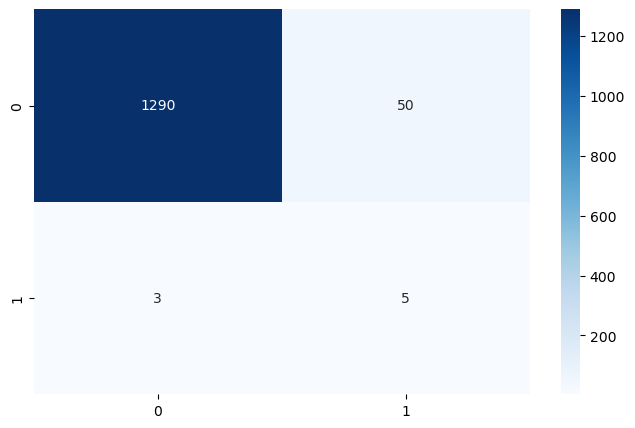

--- Random Forest (Oversampling) Evaluation Completed ---
Accuracy : 0.9955
Precision: 0.625
Recall   : 0.625
F1-score : 0.625
ROC-AUC  : 0.995

[Classification Report]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1340
           1       0.62      0.62      0.62         8

    accuracy                           1.00      1348
   macro avg       0.81      0.81      0.81      1348
weighted avg       1.00      1.00      1.00      1348



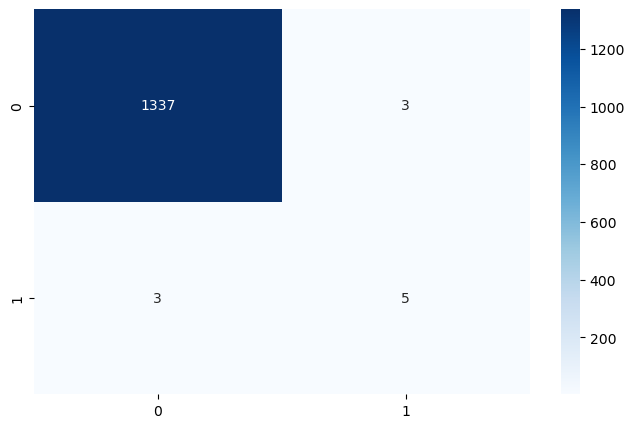


   [최종 비교] 모델별 불균형 대응 전략 성능 평가


,model_name,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.997774,1.000000,0.625,0.769231,0.927659
1,Random Forest,0.995549,0.625000,0.625,0.625000,0.931017
2,Random Forest (Balanced),0.995549,0.625000,0.625,0.625000,0.995942
3,Random Forest (Oversampling),0.995549,0.625000,0.625,0.625000,0.994963
4,Logistic Regression (Oversampling),0.960682,0.090909,0.625,0.158730,0.959095
5,Logistic Regression (Balanced),0.959199,0.087719,0.625,0.153846,0.956483



★ 최적 모델: Logistic Regression (F1-score: 0.7692)


In [19]:
# ---------------------------------------------------------
# 15. 간단한 oversampling (Train 데이터 대상)
# ---------------------------------------------------------
train_df = X_train.copy()
train_df[target_col] = y_train.values

majority_df = train_df[train_df[target_col] == 0]
minority_df = train_df[train_df[target_col] == 1]

print(f"=== Oversampling 전 클래스 비율 ===\n{train_df[target_col].value_counts(normalize=True).round(4)}")

# 소수 클래스를 다수 클래스 수만큼 복제
minority_oversampled = minority_df.sample(
    n=len(majority_df),
    replace=True,
    random_state=42
)

train_balanced = pd.concat([majority_df, minority_oversampled], axis=0)

print(f"\n=== Oversampling 후 클래스 개수 ===\n{train_balanced[target_col].value_counts().sort_index()}")

X_train_over = train_balanced.drop(columns=[target_col])
y_train_over = train_balanced[target_col]

# ---------------------------------------------------------
# 16~17. Oversampling 데이터로 모델 학습 및 평가
# ---------------------------------------------------------
# Logistic Regression (Oversampling)
result_log_over = evaluate_binary_model(
    LogisticRegression(max_iter=3000, random_state=42),
    X_train_over, y_train_over, X_test, y_test,
    model_name="Logistic Regression (Oversampling)"
)

# Random Forest (Oversampling)
result_rf_over = evaluate_binary_model(
    RandomForestClassifier(n_estimators=300, random_state=42),
    X_train_over, y_train_over, X_test, y_test,
    model_name="Random Forest (Oversampling)"
)

# ---------------------------------------------------------
# 18. 불균형 대응 방법 전체 비교표 통합
# ---------------------------------------------------------
# 모든 실험 결과를 하나의 리스트에 담아 데이터프레임으로 변환
all_results = [
    result_log, result_log_balanced, result_log_over,
    result_rf, result_rf_balanced, result_rf_over
]

imbalance_compare = pd.DataFrame(all_results).sort_values("f1", ascending=False).reset_index(drop=True)

print("\n" + "="*50)
print("   [최종 비교] 모델별 불균형 대응 전략 성능 평가")
print("="*50)

# 시각적으로 지표만 확인하기 위해 'model' 객체 컬럼은 숨기고 출력
display_cols = ['model_name', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']
display(imbalance_compare[display_cols])

# ---------------------------------------------------------
# [Tip] 가장 우수한 모델 객체 꺼내기
# ---------------------------------------------------------
best_model_info = imbalance_compare.iloc[0]
print(f"\n★ 최적 모델: {best_model_info['model_name']} (F1-score: {round(best_model_info['f1'], 4)})")

# 실제 모델 객체가 필요할 때:
# final_model = best_model_info['model']

=== Random Forest 중요 변수 ===


,feature,importance
1,Filling_Time,0.136251
8,Max_Injection_Speed,0.123671
12,Max_Switch_Over_Pressure,0.096899
5,Cushion_Position,0.083537
0,Injection_Time,0.060094
11,Max_Injection_Pressure,0.053318
2,Plasticizing_Time,0.048994
13,Max_Back_Pressure,0.037263
14,Average_Back_Pressure,0.035466
21,Hopper_Temperature,0.032603


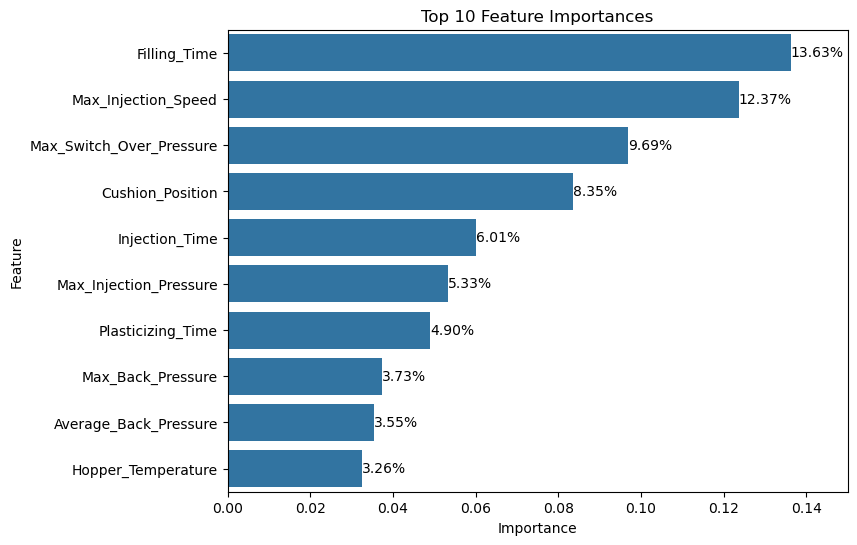

In [20]:
# ---------------------------------------------------------
# 19. 중요 변수 확인 - Random Forest 기준
# ---------------------------------------------------------
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": result_rf["model"].feature_importances_
}).sort_values("importance", ascending=False)

print("=== Random Forest 중요 변수 ===")
display(importance_df)

plt.figure(figsize=(8, 6))
ax = sns.barplot(data=importance_df.head(10), x="importance", y="feature")
for i in ax.containers:
    ax.bar_label(i, fmt="{:.2%}")
plt.xlim(0, 0.15)
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [21]:
%%time
# ---------------------------------------------------------
# 20. 하이퍼파라미터 튜닝 - Random Forest
# ---------------------------------------------------------
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 3, 5, 10],
    "min_samples_split": [2, 5],
    "class_weight": [None, "balanced"]
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)
# 맥북 M1 : Wall time: 11.2 s

CPU times: user 419 ms, sys: 185 ms, total: 603 ms
Wall time: 10.5 s


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': [None, 'balanced'],
                         'max_depth': [None, 3, 5, 10],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200, 300]},
             scoring='f1')


=== GridSearchCV 결과 ===
Best Params: {'class_weight': None, 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1: 0.7992

=== Tuned Random Forest 결과 ===
Accuracy : 0.9978
Precision: 1.0
Recall   : 0.625
F1-score : 0.7692
ROC-AUC  : 0.9928

[Classification Report]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1340
           1       1.00      0.62      0.77         8

    accuracy                           1.00      1348
   macro avg       1.00      0.81      0.88      1348
weighted avg       1.00      1.00      1.00      1348



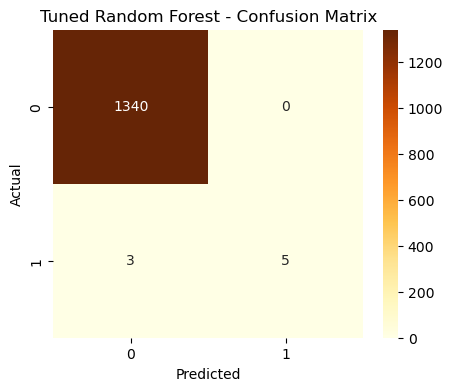

In [22]:
print("\n=== GridSearchCV 결과 ===")
print("Best Params:", grid.best_params_)
print("Best CV F1:", round(grid.best_score_, 4))

best_rf = grid.best_estimator_
best_rf_pred = best_rf.predict(X_test)
best_rf_score = best_rf.predict_proba(X_test)[:, 1]

print("\n=== Tuned Random Forest 결과 ===")
print("Accuracy :", round(accuracy_score(y_test, best_rf_pred), 4))
print("Precision:", round(precision_score(y_test, best_rf_pred, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, best_rf_pred, zero_division=0), 4))
print("F1-score :", round(f1_score(y_test, best_rf_pred, zero_division=0), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, best_rf_score), 4))
print("\n[Classification Report]")
print(classification_report(y_test, best_rf_pred, zero_division=0))

cm_best_rf = confusion_matrix(y_test, best_rf_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_best_rf, annot=True, fmt="d", cmap="YlOrBr")
plt.title("Tuned Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [23]:
# end